# Figure 1(Difficulty)

1. Load Difficulty Result for python 

In [1]:
d_viz_target = input("INPUT 'visualization_target for difficulty RUN_ID'(e.g., run_id_111110000): ")

print(f'Figure will be drawn based on the {d_viz_target} dataset')

Figure will be drawn based on the run_id_111110000 dataset


In [2]:
import pandas as pd
import numpy as np
from datetime import datetime
import os
from glob import glob

from setting_for_sdm.path_setting import path_list
from setting_for_sdm.date_setting import Date_Setting

import lib.annotation.tools.Result_Prep as rp

import lib.stats.stats as st
from lib.utils.file_io import *
from lib.utils.statistics import *
from lib.utils.settings import set_matplotlib
from matplotlib import pyplot as plt
import matplotlib as mpl
import lib.visualization.plot_generator as PlotGen
import lib.visualization.figure_setting as figure_setting

mpl.rcParams.update(figure_setting.fig_setting)




In [3]:
viz_dir = f'{path_list["data_root_dir"]}/result/annotate_difficulty/{d_viz_target}'
data_dir = f"{viz_dir}/data/csv"
option_dict = load_json(f"{viz_dir}/option.json")
output_dir = create_dir('./fig/')
date_range = 'Weekly'

In [4]:
path = f"{viz_dir}/{option_dict['operation_option']['llm_model']}"
file_list = os.listdir(path)
ver_list = sorted([y for y in [x for x in file_list if x.isdigit()]])


In [5]:
r_p = rp.Result_Prep()
tot_calc = pd.DataFrame()
for listid in ver_list:
    df = r_p.make_one_file(listid, path)
    if isinstance(df, pd.core.frame.DataFrame):
        # df = r_p.pp_df(df, 5)
        # df = r_p.calc_rate_byweek(df)
        tot_calc = pd.concat([tot_calc, df], axis = 0)

    

In [6]:
tmp = load_df('/mnt/hdd/mghan/so_data_availability/result/tag/run_id_100/data', ['cdate' , 'id' , 'tag', 'cnt', 'tot_cnt', 'pct'])

    

100%|██████████| 153/153 [00:06<00:00, 24.19it/s]


In [7]:
df = tot_calc[['creationdate', 'id', 'result']].drop_duplicates()

In [8]:
ids = (
    (df.groupby('id')['result'].count() == 1)
    .reset_index(name='is_one')
    .query('is_one == True')['id']
)

In [9]:
tag_tmp = tmp[tmp['id'].isin(ids)]

In [10]:
tag_tmp

,cdate,id,tag,cnt,tot_cnt,pct
158,2021-06-08,67891947,pandas,1,3,0.333333
159,2021-06-08,67891947,python-requests,1,3,0.333333
160,2021-06-08,67891947,edamam-api,1,3,0.333333
231,2021-06-08,67892569,pandas,1,3,0.333333
232,2021-06-08,67892569,dataframe,1,3,0.333333
...,...,...,...,...,...,...
1525297,2024-03-28,78240245,c++,1,2,0.500000
1525298,2024-03-28,78240245,pybind11,1,2,0.500000
1525354,2024-03-28,78240764,variables,1,3,0.333333
1525355,2024-03-28,78240764,calculator,1,3,0.333333


In [11]:
tag_list = list(tag_tmp[tag_tmp['cdate'] < "2022-11-30"].groupby(['tag'])['pct'].sum().reset_index().sort_values(by = ['pct'], ascending=False)['tag'])

In [12]:
topic_num = int(len(tag_list)*0.2)

In [13]:
top_list = tag_list[:topic_num]

In [14]:
bot_list = tag_list[-topic_num : ]

In [15]:
tag_list

['pandas',
 'python-3.x',
 'dataframe',
 'django',
 'numpy',
 'list',
 'tkinter',
 'matplotlib',
 'dictionary',
 'selenium',
 'json',
 'tensorflow',
 'discord.py',
 'web-scraping',
 'csv',
 'string',
 'flask',
 'function',
 'pygame',
 'loops',
 'arrays',
 'regex',
 'beautifulsoup',
 'for-loop',
 'opencv',
 'pytorch',
 'python-requests',
 'html',
 'keras',
 'plotly',
 'discord',
 'datetime',
 'jupyter-notebook',
 'visual-studio-code',
 'machine-learning',
 'pip',
 'scikit-learn',
 'pyspark',
 'pyqt5',
 'sqlalchemy',
 'excel',
 'django-models',
 'if-statement',
 'django-rest-framework',
 'kivy',
 'selenium-webdriver',
 'algorithm',
 'oop',
 'javascript',
 'class',
 'multithreading',
 'sqlite',
 'sql',
 'pytest',
 'seaborn',
 'deep-learning',
 'mysql',
 'math',
 'docker',
 'windows',
 'while-loop',
 'nlp',
 'django-views',
 'plotly-dash',
 'file',
 'scipy',
 'postgresql',
 'recursion',
 'pycharm',
 'sorting',
 'fastapi',
 'amazon-web-services',
 'apache-spark',
 'python-typing',
 'python-

In [16]:
result_df = df[df['id'].isin(ids)].copy()

In [17]:
result_df['result'] = result_df['result'].str.replace('<Difficulty Level>', '')

In [18]:
chk = pd.merge(result_df, tmp, on = 'id')
chk['rel_week'] = (pd.to_datetime(chk['creationdate']) - datetime(2022, 11, 30)).dt.days //7
tot_cnt = chk.groupby('rel_week')['cnt'].sum().reset_index()
chk['top_yn'] = chk['tag'].apply(lambda x :x in top_list)
chk['bot_yn'] = chk['tag'].apply(lambda x :x in bot_list)

chk['top_q'] = chk['top_yn'] * chk['pct']
chk['bot_q'] = chk['bot_yn'] * chk['pct']

top_cnt = chk.groupby(['rel_week'])['top_q'].sum().reset_index()
bot_cnt = chk.groupby(['rel_week'])['bot_q'].sum().reset_index()



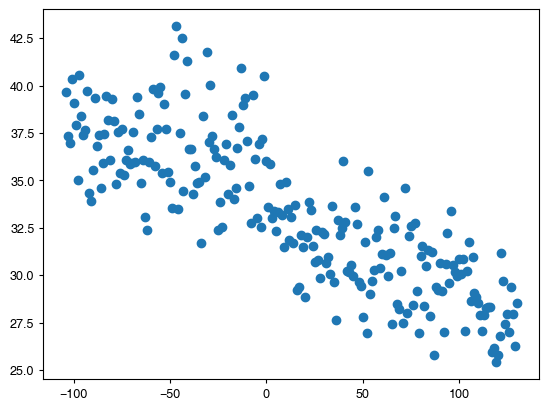

In [19]:
top_df = pd.merge(tot_cnt, top_cnt, on = 'rel_week')
top_df['ratio'] = top_df['top_q']/top_df['cnt']*100
plt.scatter(top_df['rel_week'], top_df['ratio'])

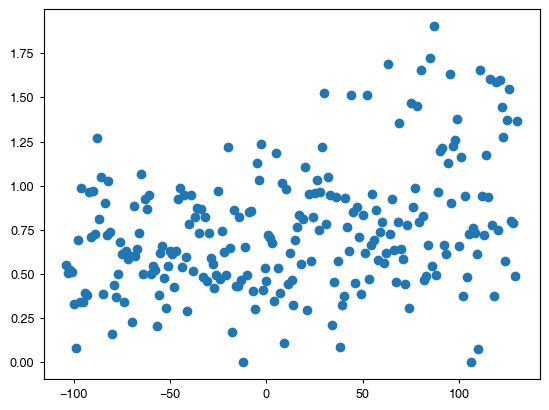

In [20]:
bot_df = pd.merge(tot_cnt, bot_cnt, on = 'rel_week')
bot_df['ratio'] = bot_df['bot_q']/bot_df['cnt']*100
plt.scatter(bot_df['rel_week'], bot_df['ratio'])

In [21]:
chk

,creationdate,id,result,cdate,tag,cnt,tot_cnt,pct,rel_week,top_yn,bot_yn,top_q,bot_q
0,2020-12-02,65101937,0,2020-12-02,list,1,1,1.000000,-104,True,False,1.000000,0.0
1,2020-12-02,65102854,1,2020-12-02,django,1,2,0.500000,-104,True,False,0.500000,0.0
2,2020-12-02,65102854,1,2020-12-02,django-rest-framework,1,2,0.500000,-104,True,False,0.500000,0.0
3,2020-12-02,65103014,1,2020-12-02,pytorch,1,1,1.000000,-104,True,False,1.000000,0.0
4,2020-12-02,65104102,1,2020-12-02,tensorflow,1,1,1.000000,-104,True,False,1.000000,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
71944,2025-05-31,79646981,1,2025-05-31,selenium-webdriver,1,2,0.500000,130,True,False,0.500000,0.0
71945,2025-05-31,79646981,1,2025-05-31,headless,1,2,0.500000,130,False,True,0.000000,0.5
71946,2025-05-31,79647009,2,2025-05-31,binance,1,3,0.333333,130,True,False,0.333333,0.0
71947,2025-05-31,79647009,2,2025-05-31,cryptocurrency,1,3,0.333333,130,False,False,0.000000,0.0


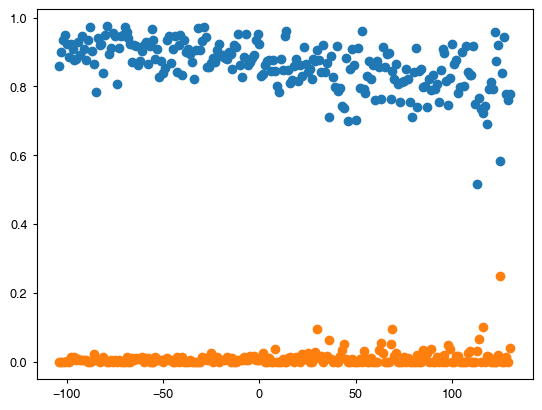

In [22]:
basic_df = result_df[result_df['result'] =='0' ]
basic_df = pd.merge(basic_df, tmp, on = 'id')
basic_df['rel_week'] = (pd.to_datetime(basic_df['creationdate']) - datetime(2022, 11, 30)).dt.days //7
basic_df['top_yn'] = basic_df['tag'].apply(lambda x :x in top_list)
basic_df['bot_yn'] = basic_df['tag'].apply(lambda x :x in bot_list)
basic_tot_q = basic_df.groupby(['rel_week'])['pct'].sum().reset_index(name='tot_q')
basic_df['top_q'] = basic_df['top_yn'] * basic_df['pct']
basic_df['bot_q'] = basic_df['bot_yn'] * basic_df['pct']
basic_top_q = basic_df.groupby(['rel_week'])['top_q'].sum().reset_index()
basic_bot_q = basic_df.groupby(['rel_week'])['bot_q'].sum().reset_index()

top_df = pd.merge(basic_tot_q, basic_top_q, on = 'rel_week')
bot_df = pd.merge(basic_tot_q, basic_bot_q, on = 'rel_week')
top_df['ratio']= top_df['top_q'] / top_df['tot_q']
bot_df['ratio']= bot_df['bot_q'] / bot_df['tot_q']

plt.scatter(top_df['rel_week'], top_df['ratio'])
plt.scatter(bot_df['rel_week'], bot_df['ratio'])


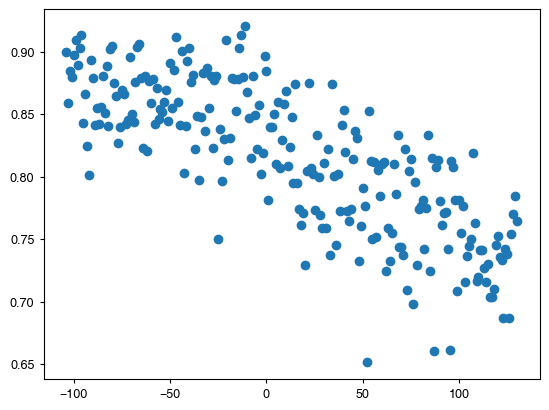

In [23]:
basic_df = result_df[result_df['result'] =='1' ]
basic_df = pd.merge(basic_df, tmp, on = 'id')
basic_df['rel_week'] = (pd.to_datetime(basic_df['creationdate']) - datetime(2022, 11, 30)).dt.days //7
basic_df['top_yn'] = basic_df['tag'].apply(lambda x :x in top_list)
basic_df['bot_yn'] = basic_df['tag'].apply(lambda x :x in bot_list)
basic_tot_q = basic_df.groupby(['rel_week'])['pct'].sum().reset_index(name='tot_q')
basic_df['top_q'] = basic_df['top_yn'] * basic_df['pct']
basic_df['bot_q'] = basic_df['bot_yn'] * basic_df['pct']
basic_top_q = basic_df.groupby(['rel_week'])['top_q'].sum().reset_index()
basic_bot_q = basic_df.groupby(['rel_week'])['bot_q'].sum().reset_index()

top_df = pd.merge(basic_tot_q, basic_top_q, on = 'rel_week')
bot_df = pd.merge(basic_tot_q, basic_bot_q, on = 'rel_week')
top_df['ratio']= top_df['top_q'] / top_df['tot_q']
bot_df['ratio']= bot_df['bot_q'] / bot_df['tot_q']

plt.scatter(top_df['rel_week'], top_df['ratio'])


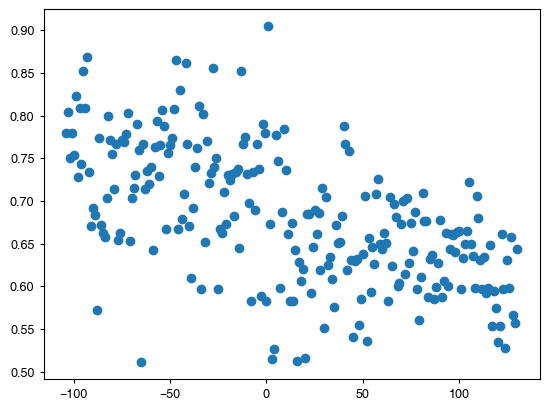

In [24]:
basic_df = result_df[result_df['result'] =='2' ]
basic_df = pd.merge(basic_df, tmp, on = 'id')
basic_df['rel_week'] = (pd.to_datetime(basic_df['creationdate']) - datetime(2022, 11, 30)).dt.days //7
basic_df['top_yn'] = basic_df['tag'].apply(lambda x :x in top_list)
basic_df['bot_yn'] = basic_df['tag'].apply(lambda x :x in bot_list)
basic_tot_q = basic_df.groupby(['rel_week'])['pct'].sum().reset_index(name='tot_q')
basic_df['top_q'] = basic_df['top_yn'] * basic_df['pct']
basic_df['bot_q'] = basic_df['bot_yn'] * basic_df['pct']
basic_top_q = basic_df.groupby(['rel_week'])['top_q'].sum().reset_index()
basic_bot_q = basic_df.groupby(['rel_week'])['bot_q'].sum().reset_index()

top_df = pd.merge(basic_tot_q, basic_top_q, on = 'rel_week')
bot_df = pd.merge(basic_tot_q, basic_bot_q, on = 'rel_week')
top_df['ratio']= top_df['top_q'] / top_df['tot_q']
bot_df['ratio']= bot_df['bot_q'] / bot_df['tot_q']

plt.scatter(top_df['rel_week'], top_df['ratio'])



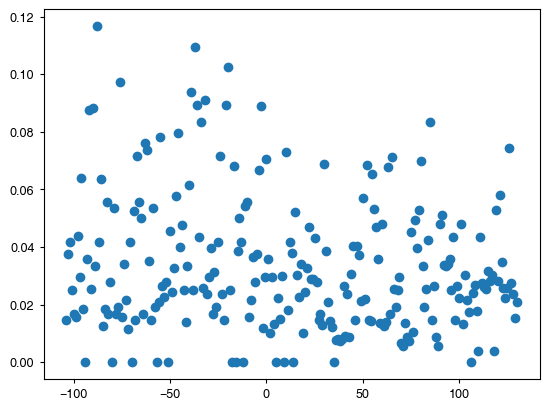

In [25]:
plt.scatter(bot_df['rel_week'], bot_df['ratio'])

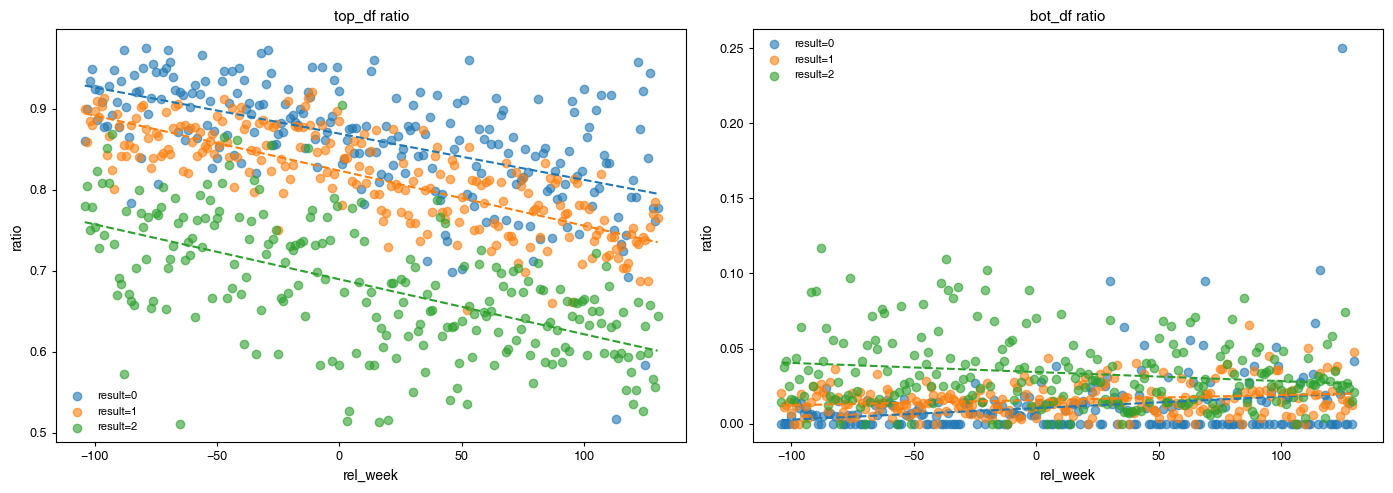

In [26]:
import numpy as np

def make_dfs(result_val):
    basic_df = result_df[result_df['result'] == result_val]
    basic_df = pd.merge(basic_df, tmp, on='id')
    basic_df['rel_week'] = (pd.to_datetime(basic_df['creationdate']) - datetime(2022, 11, 30)).dt.days // 7
    basic_df['top_yn'] = basic_df['tag'].apply(lambda x: x in top_list)
    basic_df['bot_yn'] = basic_df['tag'].apply(lambda x: x in bot_list)

    basic_tot_q = basic_df.groupby('rel_week')['pct'].sum().reset_index(name='tot_q')
    basic_df['top_q'] = basic_df['top_yn'] * basic_df['pct']
    basic_df['bot_q'] = basic_df['bot_yn'] * basic_df['pct']
    basic_top_q = basic_df.groupby('rel_week')['top_q'].sum().reset_index()
    basic_bot_q = basic_df.groupby('rel_week')['bot_q'].sum().reset_index()

    top_df = pd.merge(basic_tot_q, basic_top_q, on='rel_week')
    bot_df = pd.merge(basic_tot_q, basic_bot_q, on='rel_week')
    top_df['ratio'] = top_df['top_q'] / top_df['tot_q']
    bot_df['ratio'] = bot_df['bot_q'] / bot_df['tot_q']
    return top_df, bot_df

results = ['0', '1', '2']
top_results = {}
bot_results = {}
for r in results:
    top_results[r], bot_results[r] = make_dfs(r)

def plot_with_trend(ax, dfs, title):
    for r, df in dfs.items():
        df = df.dropna(subset=['ratio'])
        ax.scatter(df['rel_week'], df['ratio'], label=f'result={r}', alpha=0.6)
        if len(df) > 1:
            z = np.polyfit(df['rel_week'], df['ratio'], 1)
            xs = np.array([df['rel_week'].min(), df['rel_week'].max()])
            ax.plot(xs, np.polyval(z, xs), linestyle='--')
    ax.set_title(title)
    ax.set_xlabel('rel_week')
    ax.set_ylabel('ratio')
    ax.legend()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
plot_with_trend(axes[0], top_results, 'top_df ratio')
plot_with_trend(axes[1], bot_results, 'bot_df ratio')
plt.tight_layout()
plt.show()

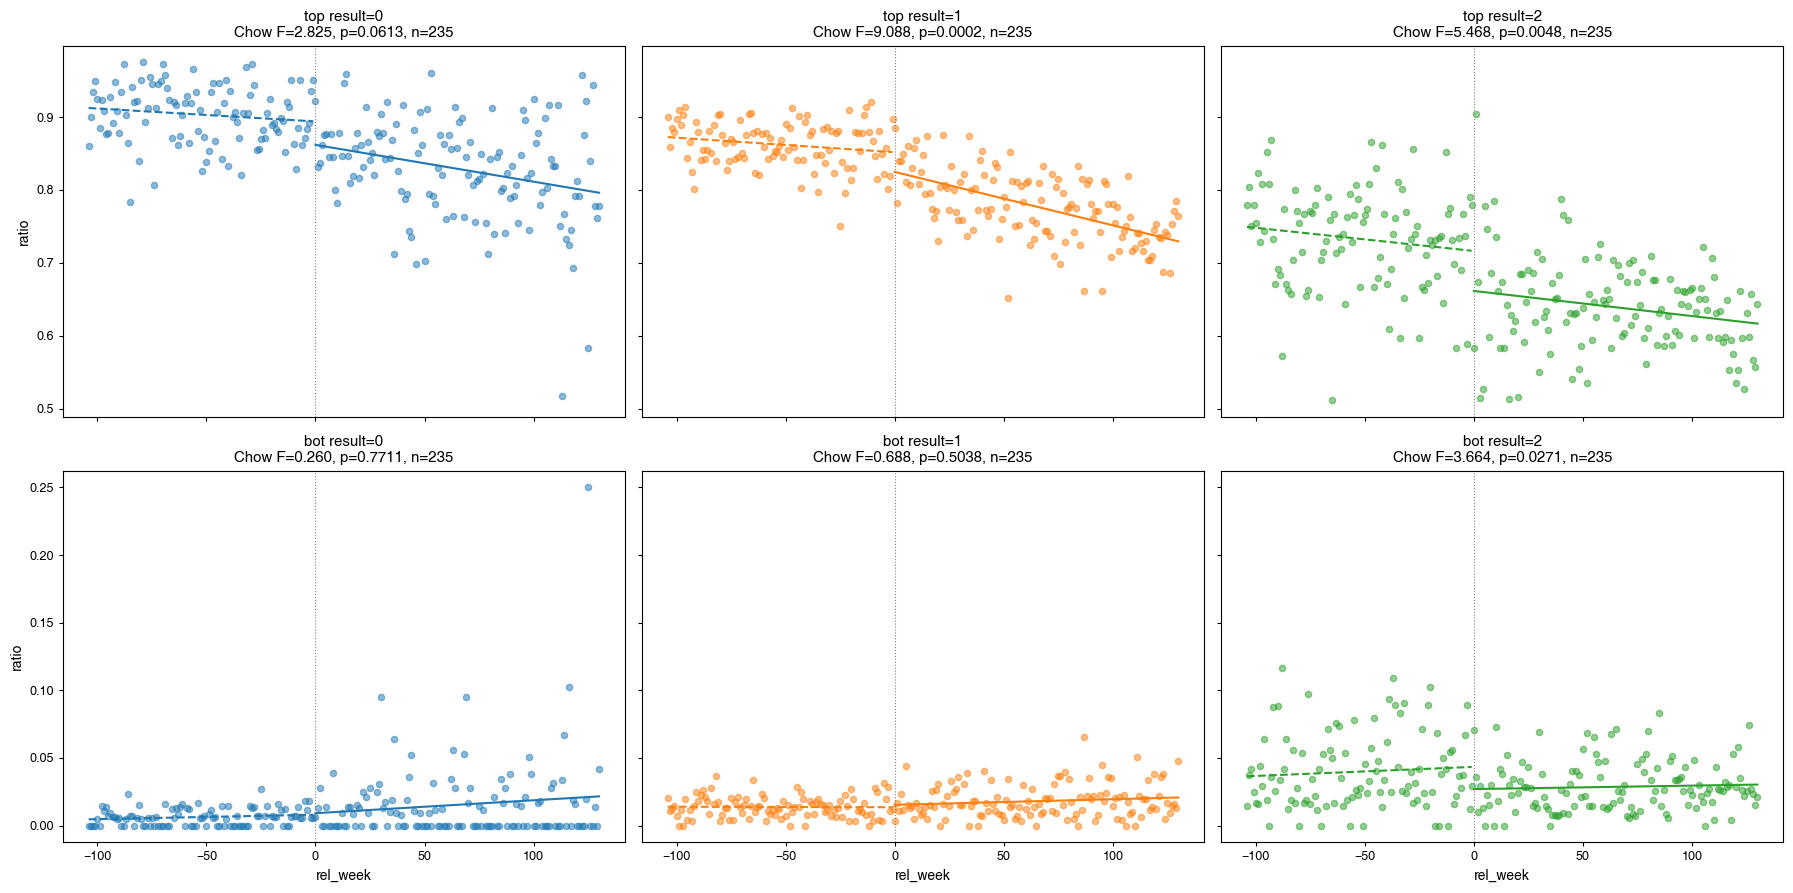

panel result           F           p       n
top   0            2.825      0.0613     235
bot   0            0.260      0.7711     235
top   1            9.088      0.0002     235
bot   1            0.688      0.5038     235
top   2            5.468      0.0048     235
bot   2            3.664      0.0271     235


In [27]:
import numpy as np
from scipy import stats

def chow_test(x, y, breakpoint=0):
    """rel_week=breakpoint 기준 전(<0)/후(>=0) 구조변화 검정"""
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    mask = ~(np.isnan(x) | np.isnan(y))
    x, y = x[mask], y[mask]

    def rss(xx, yy):
        if len(xx) < 2:
            return 0.0, 0
        b = np.polyfit(xx, yy, 1)
        resid = yy - np.polyval(b, xx)
        return np.sum(resid**2), len(xx)

    rss_pool, n = rss(x, y)
    m1 = x < breakpoint
    m2 = x >= breakpoint
    rss1, n1 = rss(x[m1], y[m1])
    rss2, n2 = rss(x[m2], y[m2])

    k = 2  # 파라미터 수 (절편, 기울기)
    if n1 < k or n2 < k or (n - 2 * k) <= 0:
        return np.nan, np.nan, np.nan

    num = (rss_pool - (rss1 + rss2)) / k
    den = (rss1 + rss2) / (n - 2 * k)
    F = num / den
    p = 1 - stats.f.cdf(F, k, n - 2 * k)
    return F, p, n

results = ['0', '1', '2']
colors = {'0': 'tab:blue', '1': 'tab:orange', '2': 'tab:green'}

fig, axes = plt.subplots(2, 3, figsize=(18, 9), sharex=True, sharey='row')

def plot_panel(ax, df, r, label):
    df = df.dropna(subset=['ratio'])
    x, y = df['rel_week'].values, df['ratio'].values
    ax.scatter(x, y, color=colors[r], alpha=0.5, s=20)

    # 전후 각각 추세선
    for mask, ls in [(x < 0, '--'), (x >= 0, '-')]:
        if mask.sum() > 1:
            b = np.polyfit(x[mask], y[mask], 1)
            xs = np.array([x[mask].min(), x[mask].max()])
            ax.plot(xs, np.polyval(b, xs), color=colors[r], linestyle=ls)

    ax.axvline(0, color='gray', lw=0.8, ls=':')
    F, p, n = chow_test(x, y, 0)
    ax.set_title(f'{label} result={r}\nChow F={F:.3f}, p={p:.4f}, n={n}')

for j, r in enumerate(results):
    plot_panel(axes[0, j], top_results[r], r, 'top')
    plot_panel(axes[1, j], bot_results[r], r, 'bot')

for ax in axes[1, :]:
    ax.set_xlabel('rel_week')
for ax in axes[:, 0]:
    ax.set_ylabel('ratio')

plt.tight_layout()
plt.show()

# 결과 표로도 출력
print(f"{'panel':<6}{'result':<8}{'F':>10}{'p':>12}{'n':>8}")
for r in results:
    for label, dfs in [('top', top_results), ('bot', bot_results)]:
        df = dfs[r].dropna(subset=['ratio'])
        F, p, n = chow_test(df['rel_week'], df['ratio'], 0)
        print(f"{label:<6}{r:<8}{F:>10.3f}{p:>12.4f}{n:>8}")

In [28]:
result_df

,creationdate,id,result
20,2020-11-01,64628635,0
25,2020-11-01,64629998,1
35,2020-11-01,64630633,1
45,2020-11-01,64631086,1
55,2020-11-01,64631540,0
...,...,...,...
95,2025-05-31,79646778,1
110,2025-05-31,79646896,1
115,2025-05-31,79646918,2
120,2025-05-31,79646981,1


In [29]:
df_tot = pd.merge(result_df, tmp, on = 'id')
df_tot['rel_week'] = (pd.to_datetime(df_tot['creationdate']) - datetime(2022, 11, 30)).dt.days // 7
df_top_tot = df_tot[df_tot['tag'].isin(top_list)]
df_bot_tot = df_tot[df_tot['tag'].isin(bot_list)]
df_top_tot_pct = df_top_tot.groupby(['rel_week'])['pct'].sum().reset_index(name = 'tot_pct')
df_bot_tot_pct = df_top_tot.groupby(['rel_week'])['pct'].sum().reset_index(name = 'tot_pct')
df_top_result_pct = df_top_tot.groupby(['rel_week', 'result'])['pct'].sum().reset_index(name = 'pct')
df_top_viz = pd.merge(df_top_tot_pct, df_top_result_pct, on = 'rel_week')
df_top_viz['ratio'] = df_top_viz['pct']/df_top_viz['tot_pct']

/tmp/ipykernel_2109290/1473454940.py:20: UserWarning: Glyph 53664 (\N{HANGUL SYLLABLE TO}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_2109290/1473454940.py:20: UserWarning: Glyph 54589 (\N{HANGUL SYLLABLE PIG}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_2109290/1473454940.py:20: UserWarning: Glyph 48324 (\N{HANGUL SYLLABLE BYEOL}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_2109290/1473454940.py:20: UserWarning: Glyph 45817 (\N{HANGUL SYLLABLE DANG}) missing from current font.
  plt.tight_layout()
/home/mghan/sopjt/git/so_difficulty_measure/venv_so_difficulty_measure/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 53664 (\N{HANGUL SYLLABLE TO}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/home/mghan/sopjt/git/so_difficulty_measure/venv_so_difficulty_measure/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 54589 (\N{HANGUL SYLLABLE PIG}) miss

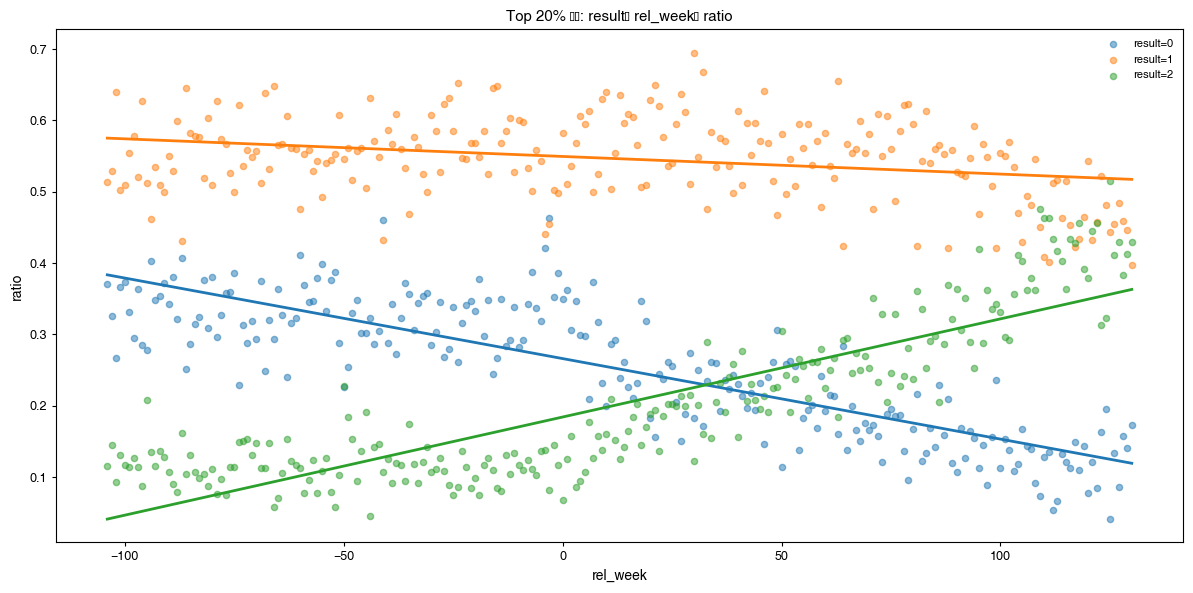

In [30]:
import numpy as np

colors = {'0': 'tab:blue', '1': 'tab:orange', '2': 'tab:green'}

fig, ax = plt.subplots(figsize=(12, 6))

for r, sub in df_top_viz.groupby('result'):
    sub = sub.sort_values('rel_week')
    ax.scatter(sub['rel_week'], sub['ratio'],
               color=colors.get(str(r)), alpha=0.5, s=20, label=f'result={r}')
    if len(sub) > 1:
        z = np.polyfit(sub['rel_week'], sub['ratio'], 1)
        xs = np.array([sub['rel_week'].min(), sub['rel_week'].max()])
        ax.plot(xs, np.polyval(z, xs), color=colors.get(str(r)), lw=2)

ax.set_xlabel('rel_week')
ax.set_ylabel('ratio')
ax.set_title('Top 20% 토픽: result별 rel_week당 ratio')
ax.legend()
plt.tight_layout()
plt.show()

/tmp/ipykernel_2109290/2599528683.py:29: UserWarning: Glyph 53664 (\N{HANGUL SYLLABLE TO}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_2109290/2599528683.py:29: UserWarning: Glyph 54589 (\N{HANGUL SYLLABLE PIG}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_2109290/2599528683.py:29: UserWarning: Glyph 48324 (\N{HANGUL SYLLABLE BYEOL}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_2109290/2599528683.py:29: UserWarning: Glyph 45817 (\N{HANGUL SYLLABLE DANG}) missing from current font.
  plt.tight_layout()
/home/mghan/sopjt/git/so_difficulty_measure/venv_so_difficulty_measure/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 53664 (\N{HANGUL SYLLABLE TO}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/home/mghan/sopjt/git/so_difficulty_measure/venv_so_difficulty_measure/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 54589 (\N{HANGUL SYLLABLE PIG}) miss

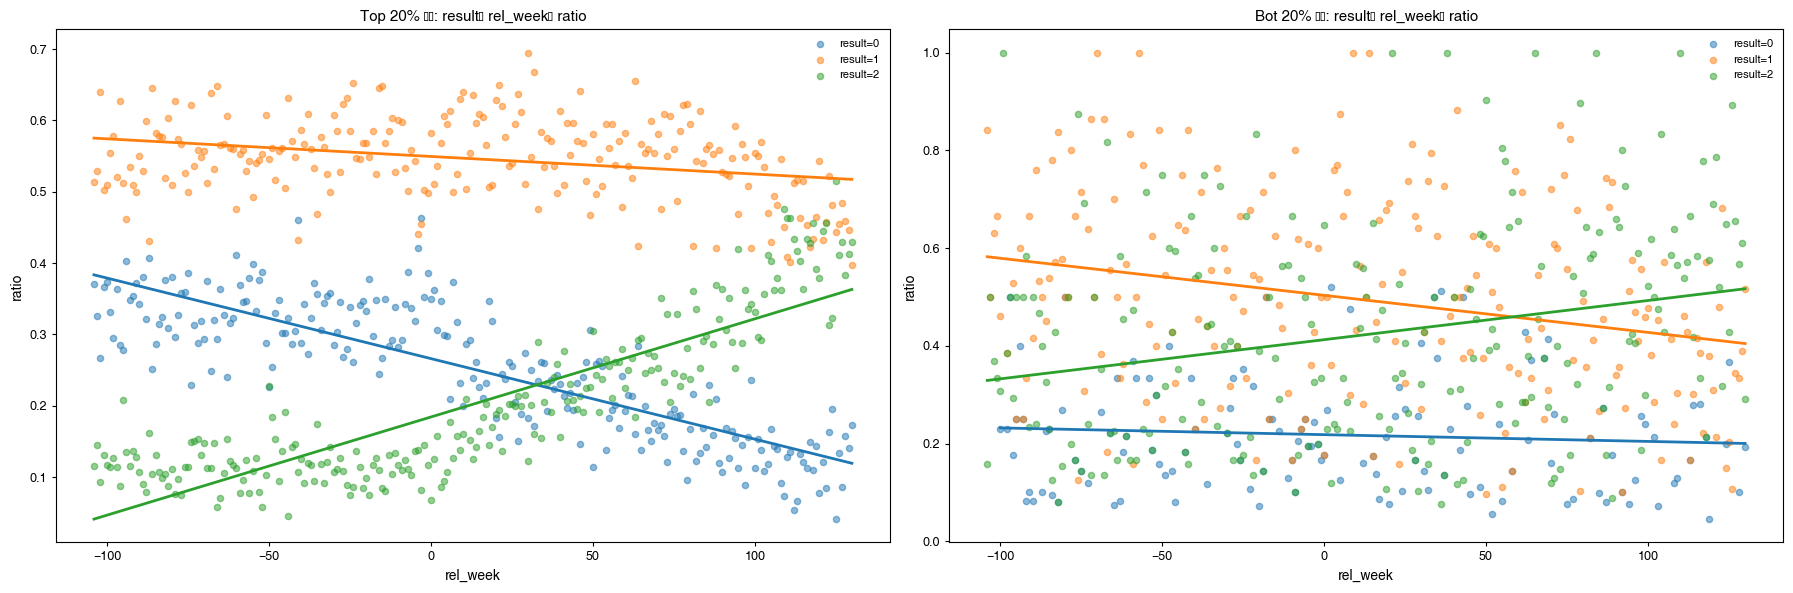

In [31]:
import numpy as np

# df_bot_viz 생성 (top과 동일한 방식)
df_bot_tot_pct = df_bot_tot.groupby(['rel_week'])['pct'].sum().reset_index(name='tot_pct')
df_bot_result_pct = df_bot_tot.groupby(['rel_week', 'result'])['pct'].sum().reset_index(name='pct')
df_bot_viz = pd.merge(df_bot_tot_pct, df_bot_result_pct, on='rel_week')
df_bot_viz['ratio'] = df_bot_viz['pct'] / df_bot_viz['tot_pct']

colors = {'0': 'tab:blue', '1': 'tab:orange', '2': 'tab:green'}

def plot_viz(ax, df, title):
    for r, sub in df.groupby('result'):
        sub = sub.sort_values('rel_week')
        ax.scatter(sub['rel_week'], sub['ratio'],
                   color=colors.get(str(r)), alpha=0.5, s=20, label=f'result={r}')
        if len(sub) > 1:
            z = np.polyfit(sub['rel_week'], sub['ratio'], 1)
            xs = np.array([sub['rel_week'].min(), sub['rel_week'].max()])
            ax.plot(xs, np.polyval(z, xs), color=colors.get(str(r)), lw=2)
    ax.set_xlabel('rel_week')
    ax.set_ylabel('ratio')
    ax.set_title(title)
    ax.legend()

fig, axes = plt.subplots(1, 2, figsize=(18, 6), sharex=True)
plot_viz(axes[0], df_top_viz, 'Top 20% 토픽: result별 rel_week당 ratio')
plot_viz(axes[1], df_bot_viz, 'Bot 20% 토픽: result별 rel_week당 ratio')

plt.tight_layout()
plt.show()

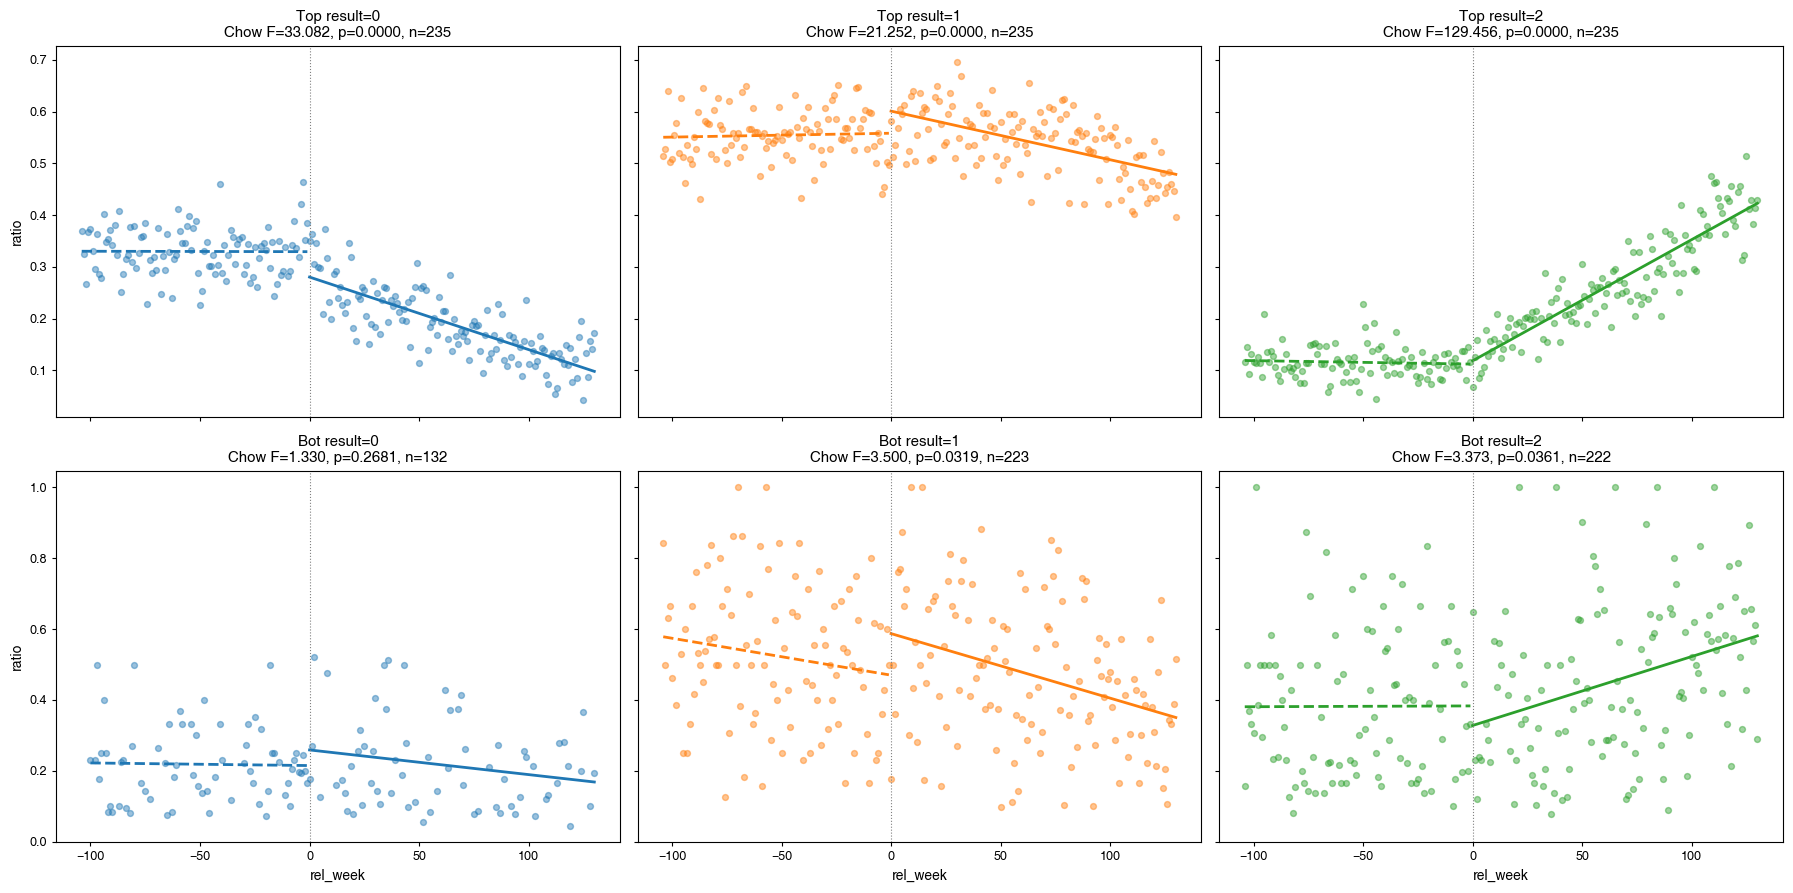

panel result           F           p       n
top   0           33.082      0.0000     235
bot   0            1.330      0.2681     132
top   1           21.252      0.0000     235
bot   1            3.500      0.0319     223
top   2          129.456      0.0000     235
bot   2            3.373      0.0361     222


In [32]:
import numpy as np
from scipy import stats

# df_bot_viz가 아직 없다면 생성
df_bot_tot_pct = df_bot_tot.groupby(['rel_week'])['pct'].sum().reset_index(name='tot_pct')
df_bot_result_pct = df_bot_tot.groupby(['rel_week', 'result'])['pct'].sum().reset_index(name='pct')
df_bot_viz = pd.merge(df_bot_tot_pct, df_bot_result_pct, on='rel_week')
df_bot_viz['ratio'] = df_bot_viz['pct'] / df_bot_viz['tot_pct']

results = ['0', '1', '2']
colors = {'0': 'tab:blue', '1': 'tab:orange', '2': 'tab:green'}

def chow_test(x, y, breakpoint=0):
    """rel_week=breakpoint 기준 전(<0)/후(>=0) 구조변화 검정"""
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    mask = ~(np.isnan(x) | np.isnan(y))
    x, y = x[mask], y[mask]

    def rss(xx, yy):
        if len(xx) < 2:
            return 0.0, len(xx)
        b = np.polyfit(xx, yy, 1)
        resid = yy - np.polyval(b, xx)
        return np.sum(resid**2), len(xx)

    rss_pool, n = rss(x, y)
    rss1, n1 = rss(x[x < breakpoint], y[x < breakpoint])
    rss2, n2 = rss(x[x >= breakpoint], y[x >= breakpoint])

    k = 2  # 절편, 기울기
    if n1 < k or n2 < k or (n - 2 * k) <= 0:
        return np.nan, np.nan, n

    F = ((rss_pool - (rss1 + rss2)) / k) / ((rss1 + rss2) / (n - 2 * k))
    p = 1 - stats.f.cdf(F, k, n - 2 * k)
    return F, p, n

def plot_panel(ax, sub, r, label):
    sub = sub.dropna(subset=['ratio'])
    x, y = sub['rel_week'].values, sub['ratio'].values
    ax.scatter(x, y, color=colors[r], alpha=0.45, s=18)

    # 0점 전후 추세선 따로
    for mask, ls in [(x < 0, '--'), (x >= 0, '-')]:
        if mask.sum() > 1:
            b = np.polyfit(x[mask], y[mask], 1)
            xs = np.array([x[mask].min(), x[mask].max()])
            ax.plot(xs, np.polyval(b, xs), color=colors[r], ls=ls, lw=2)

    ax.axvline(0, color='gray', lw=0.8, ls=':')
    F, p, n = chow_test(x, y, 0)
    ax.set_title(f'{label} result={r}\nChow F={F:.3f}, p={p:.4f}, n={n}')

fig, axes = plt.subplots(2, 3, figsize=(18, 9), sharex=True, sharey='row')

for j, r in enumerate(results):
    top_sub = df_top_viz[df_top_viz['result'].astype(str) == r]
    bot_sub = df_bot_viz[df_bot_viz['result'].astype(str) == r]
    plot_panel(axes[0, j], top_sub, r, 'Top')
    plot_panel(axes[1, j], bot_sub, r, 'Bot')

for ax in axes[1, :]:
    ax.set_xlabel('rel_week')
for ax in axes[:, 0]:
    ax.set_ylabel('ratio')

plt.tight_layout()
plt.show()

# Chow test 결과 표
print(f"{'panel':<6}{'result':<8}{'F':>10}{'p':>12}{'n':>8}")
for r in results:
    for label, df in [('top', df_top_viz), ('bot', df_bot_viz)]:
        sub = df[df['result'].astype(str) == r].dropna(subset=['ratio'])
        F, p, n = chow_test(sub['rel_week'], sub['ratio'], 0)
        print(f"{label:<6}{r:<8}{F:>10.3f}{p:>12.4f}{n:>8}")

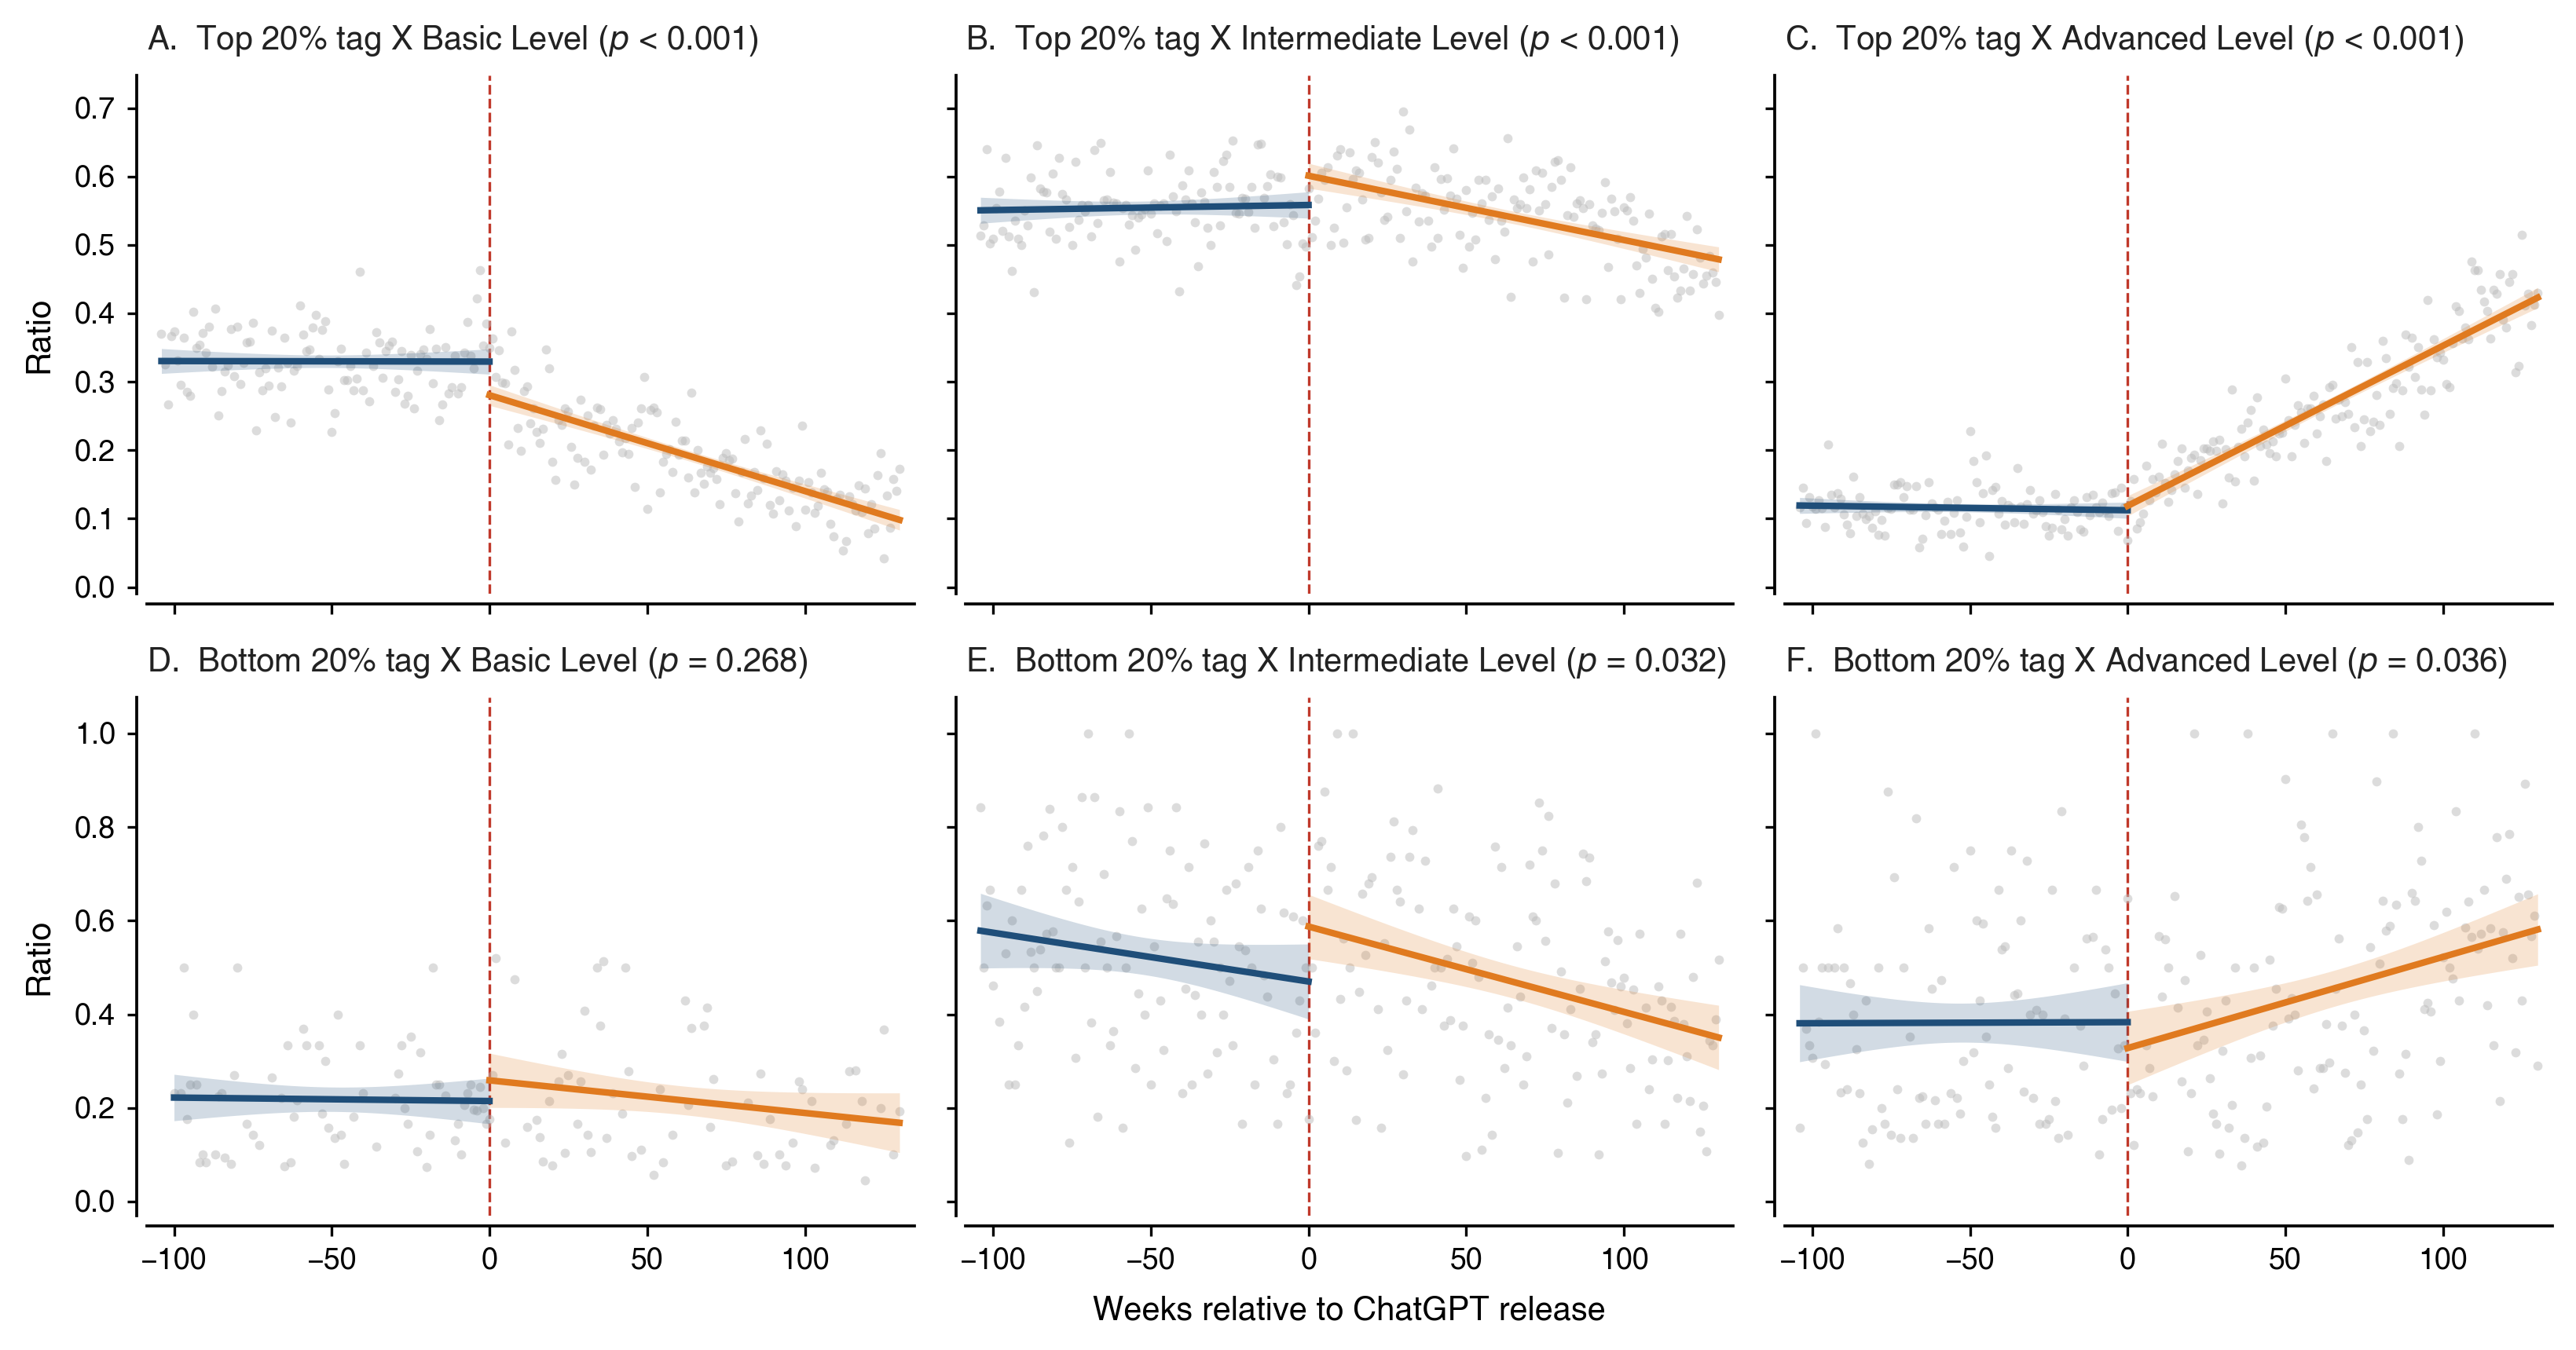

panel result           F           p       n
top   0           33.082      0.0000     235
bot   0            1.330      0.2681     132
top   1           21.252      0.0000     235
bot   1            3.500      0.0319     223
top   2          129.456      0.0000     235
bot   2            3.373      0.0361     222


In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
from scipy import stats

# ═══════════════════════════════════════════
# 공통 팔레트 (다른 figure들과 통일)
# ═══════════════════════════════════════════
PALETTE = {
    'primary': '#1f4e79',   # Before
    'accent':  '#E07A1F',   # After
    'event':   '#C0392B',   # 이벤트 점선
    'point':   '#BBBBBB',   # 산점도
}

DIFFICULTY = {'0' : 'Basic', '1' : 'Intermediate', '2' : 'Advanced'}

# mpl.rcParams.update({
#     'font.family': 'sans-serif',
#     'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans'],
#     'pdf.fonttype': 42, 'ps.fonttype': 42,
# })

# ═══════════════════════════════════════════
# 데이터 준비 (원본 그대로)
# ═══════════════════════════════════════════
df_bot_tot_pct    = df_bot_tot.groupby(['rel_week'])['pct'].sum().reset_index(name='tot_pct')
df_bot_result_pct = df_bot_tot.groupby(['rel_week', 'result'])['pct'].sum().reset_index(name='pct')
df_bot_viz = pd.merge(df_bot_tot_pct, df_bot_result_pct, on='rel_week')
df_bot_viz['ratio'] = df_bot_viz['pct'] / df_bot_viz['tot_pct']

results = ['0', '1', '2']

# ═══════════════════════════════════════════
# Chow test (원본 그대로)
# ═══════════════════════════════════════════
def chow_test(x, y, breakpoint=0):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    mask = ~(np.isnan(x) | np.isnan(y))
    x, y = x[mask], y[mask]

    def rss(xx, yy):
        if len(xx) < 2:
            return 0.0, len(xx)
        b = np.polyfit(xx, yy, 1)
        resid = yy - np.polyval(b, xx)
        return np.sum(resid**2), len(xx)

    rss_pool, n = rss(x, y)
    rss1, n1 = rss(x[x < breakpoint], y[x < breakpoint])
    rss2, n2 = rss(x[x >= breakpoint], y[x >= breakpoint])
    k = 2
    if n1 < k or n2 < k or (n - 2 * k) <= 0:
        return np.nan, np.nan, n

    F = ((rss_pool - (rss1 + rss2)) / k) / ((rss1 + rss2) / (n - 2 * k))
    p = 1 - stats.f.cdf(F, k, n - 2 * k)
    return F, p, n

# ═══════════════════════════════════════════
# 회귀 신뢰구간 계산 (CI band용)
# ═══════════════════════════════════════════
def regression_ci(x, y, xs, alpha=0.05):
    x = np.asarray(x); y = np.asarray(y); xs = np.asarray(xs)
    n = len(x)
    if n < 3:
        fit = np.full_like(xs, np.nan, dtype=float)
        return fit, fit, fit
    slope, intercept, *_ = stats.linregress(x, y)
    resid = y - (slope*x + intercept)
    s_err = np.sqrt(np.sum(resid**2) / (n - 2))
    x_mean = x.mean(); ss_x = np.sum((x - x_mean)**2)
    t_val = stats.t.ppf(1 - alpha/2, n - 2)
    ci = t_val * s_err * np.sqrt(1/n + (xs - x_mean)**2 / ss_x)
    fit = slope*xs + intercept
    return fit, fit - ci, fit + ci

# ═══════════════════════════════════════════
# 패널 그리기
# ═══════════════════════════════════════════
def plot_panel(ax, sub, r, label, panel_label,
               show_xlabel=False, show_ylabel=False):
    sub = sub.dropna(subset=['ratio'])
    x, y = sub['rel_week'].values, sub['ratio'].values
    pre, post = x < 0, x >= 0

    # 산점도
    ax.scatter(x, y, s=8, color=PALETTE['point'],
               alpha=0.5, lw=0, zorder=2, clip_on=False)

    # CI band + 회귀선 (둘 다 실선, navy/accent)
    if pre.sum() > 2:
        xs_pre = np.linspace(x[pre].min(), 0, 100)
        fit_pre, lo_pre, hi_pre = regression_ci(x[pre], y[pre], xs_pre)
        ax.fill_between(xs_pre, lo_pre, hi_pre,
                        color=PALETTE['primary'], alpha=0.2, lw=0, zorder=3)
        ax.plot(xs_pre, fit_pre,
                color=PALETTE['primary'], lw=2.0, zorder=5)

    if post.sum() > 2:
        xs_post = np.linspace(0, x[post].max(), 100)
        fit_post, lo_post, hi_post = regression_ci(x[post], y[post], xs_post)
        ax.fill_between(xs_post, lo_post, hi_post,
                        color=PALETTE['accent'], alpha=0.2, lw=0, zorder=3)
        ax.plot(xs_post, fit_post,
                color=PALETTE['accent'], lw=2.0, zorder=5)

    # 이벤트 점선
    ax.axvline(0, color=PALETTE['event'], lw=0.8, ls='--', zorder=1)

    # Title: "A. Top result 0 (p<0.001, n=231)"
    F, p, n = chow_test(x, y, 0)
    if np.isnan(p):
        p_txt = 'n.d.'
    else:
        p_txt = '$p$ < 0.001' if p < 0.001 else f'$p$ = {p:.3f}'
    prefix = f'{panel_label}.  ' if panel_label else ''
    
    ax.set_title(f'{prefix}{label} 20% tag X {DIFFICULTY[r]} Level ({p_txt})',
                 fontsize=10, loc='left', pad=8, color='#222')

    # 축 라벨
    if show_xlabel:
        ax.set_xlabel('Weeks relative to ChatGPT release',
                      fontsize=10, labelpad=6)
    if show_ylabel:
        ax.set_ylabel('Ratio', fontsize=10, labelpad=6)

    ax.tick_params(axis='both', labelsize=9, width=0.8, length=3)

    for s in ['top', 'right']:
        ax.spines[s].set_visible(False)
    ax.spines['left'].set_linewidth(0.9)
    ax.spines['bottom'].set_linewidth(0.9)
    ax.spines['left'].set_position(('outward', 3))
    ax.spines['bottom'].set_position(('outward', 3))

    ax.grid(False)
    ax.margins(x=0.02, y=0.08)

# ═══════════════════════════════════════════
# 2x3 grid
# ═══════════════════════════════════════════
fig, axes = plt.subplots(2, 3, figsize=(11, 5.8), dpi=300,
                         sharex=True, sharey='row')

panel_labels = [['A', 'B', 'C'], ['D', 'E', 'F']]

for j, r in enumerate(results):
    top_sub = df_top_viz[df_top_viz['result'].astype(str) == r]
    bot_sub = df_bot_viz[df_bot_viz['result'].astype(str) == r]

    plot_panel(axes[0, j], top_sub, r, 'Top', panel_labels[0][j],
               show_xlabel=False, show_ylabel=(j == 0))
    plot_panel(axes[1, j], bot_sub, r, 'Bottom', panel_labels[1][j],
               show_xlabel=(j == 1), show_ylabel=(j == 0))

plt.tight_layout()
# plt.savefig('top_bot_results.png', dpi=300, bbox_inches='tight', facecolor='white')
# plt.savefig('top_bot_results.pdf',           bbox_inches='tight', facecolor='white')
plt.show()

# ═══════════════════════════════════════════
# Chow test 결과 표 (원본 그대로)
# ═══════════════════════════════════════════
print(f"{'panel':<6}{'result':<8}{'F':>10}{'p':>12}{'n':>8}")
for r in results:
    for label, df in [('top', df_top_viz), ('bot', df_bot_viz)]:
        sub = df[df['result'].astype(str) == r].dropna(subset=['ratio'])
        F, p, n = chow_test(sub['rel_week'], sub['ratio'], 0)
        print(f"{label:<6}{r:<8}{F:>10.3f}{p:>12.4f}{n:>8}")

In [34]:
from statsmodels.stats.stattools import durbin_watson

for r in results:
    for label, df in [('top', df_top_viz), ('bot', df_bot_viz)]:
        sub = df[df['result'].astype(str) == r].dropna(subset=['ratio'])
        x, y = sub['rel_week'].values, sub['ratio'].values
        # 전체 회귀 잔차
        slope, intercept, *_ = stats.linregress(x, y)
        resid = y - (slope*x + intercept)
        dw = durbin_watson(resid)
        print(f"{label} result={r}: Durbin-Watson = {dw:.3f}")

top result=0: Durbin-Watson = 1.452
bot result=0: Durbin-Watson = 1.904
top result=1: Durbin-Watson = 1.683
bot result=1: Durbin-Watson = 2.042
top result=2: Durbin-Watson = 0.914
bot result=2: Durbin-Watson = 1.949


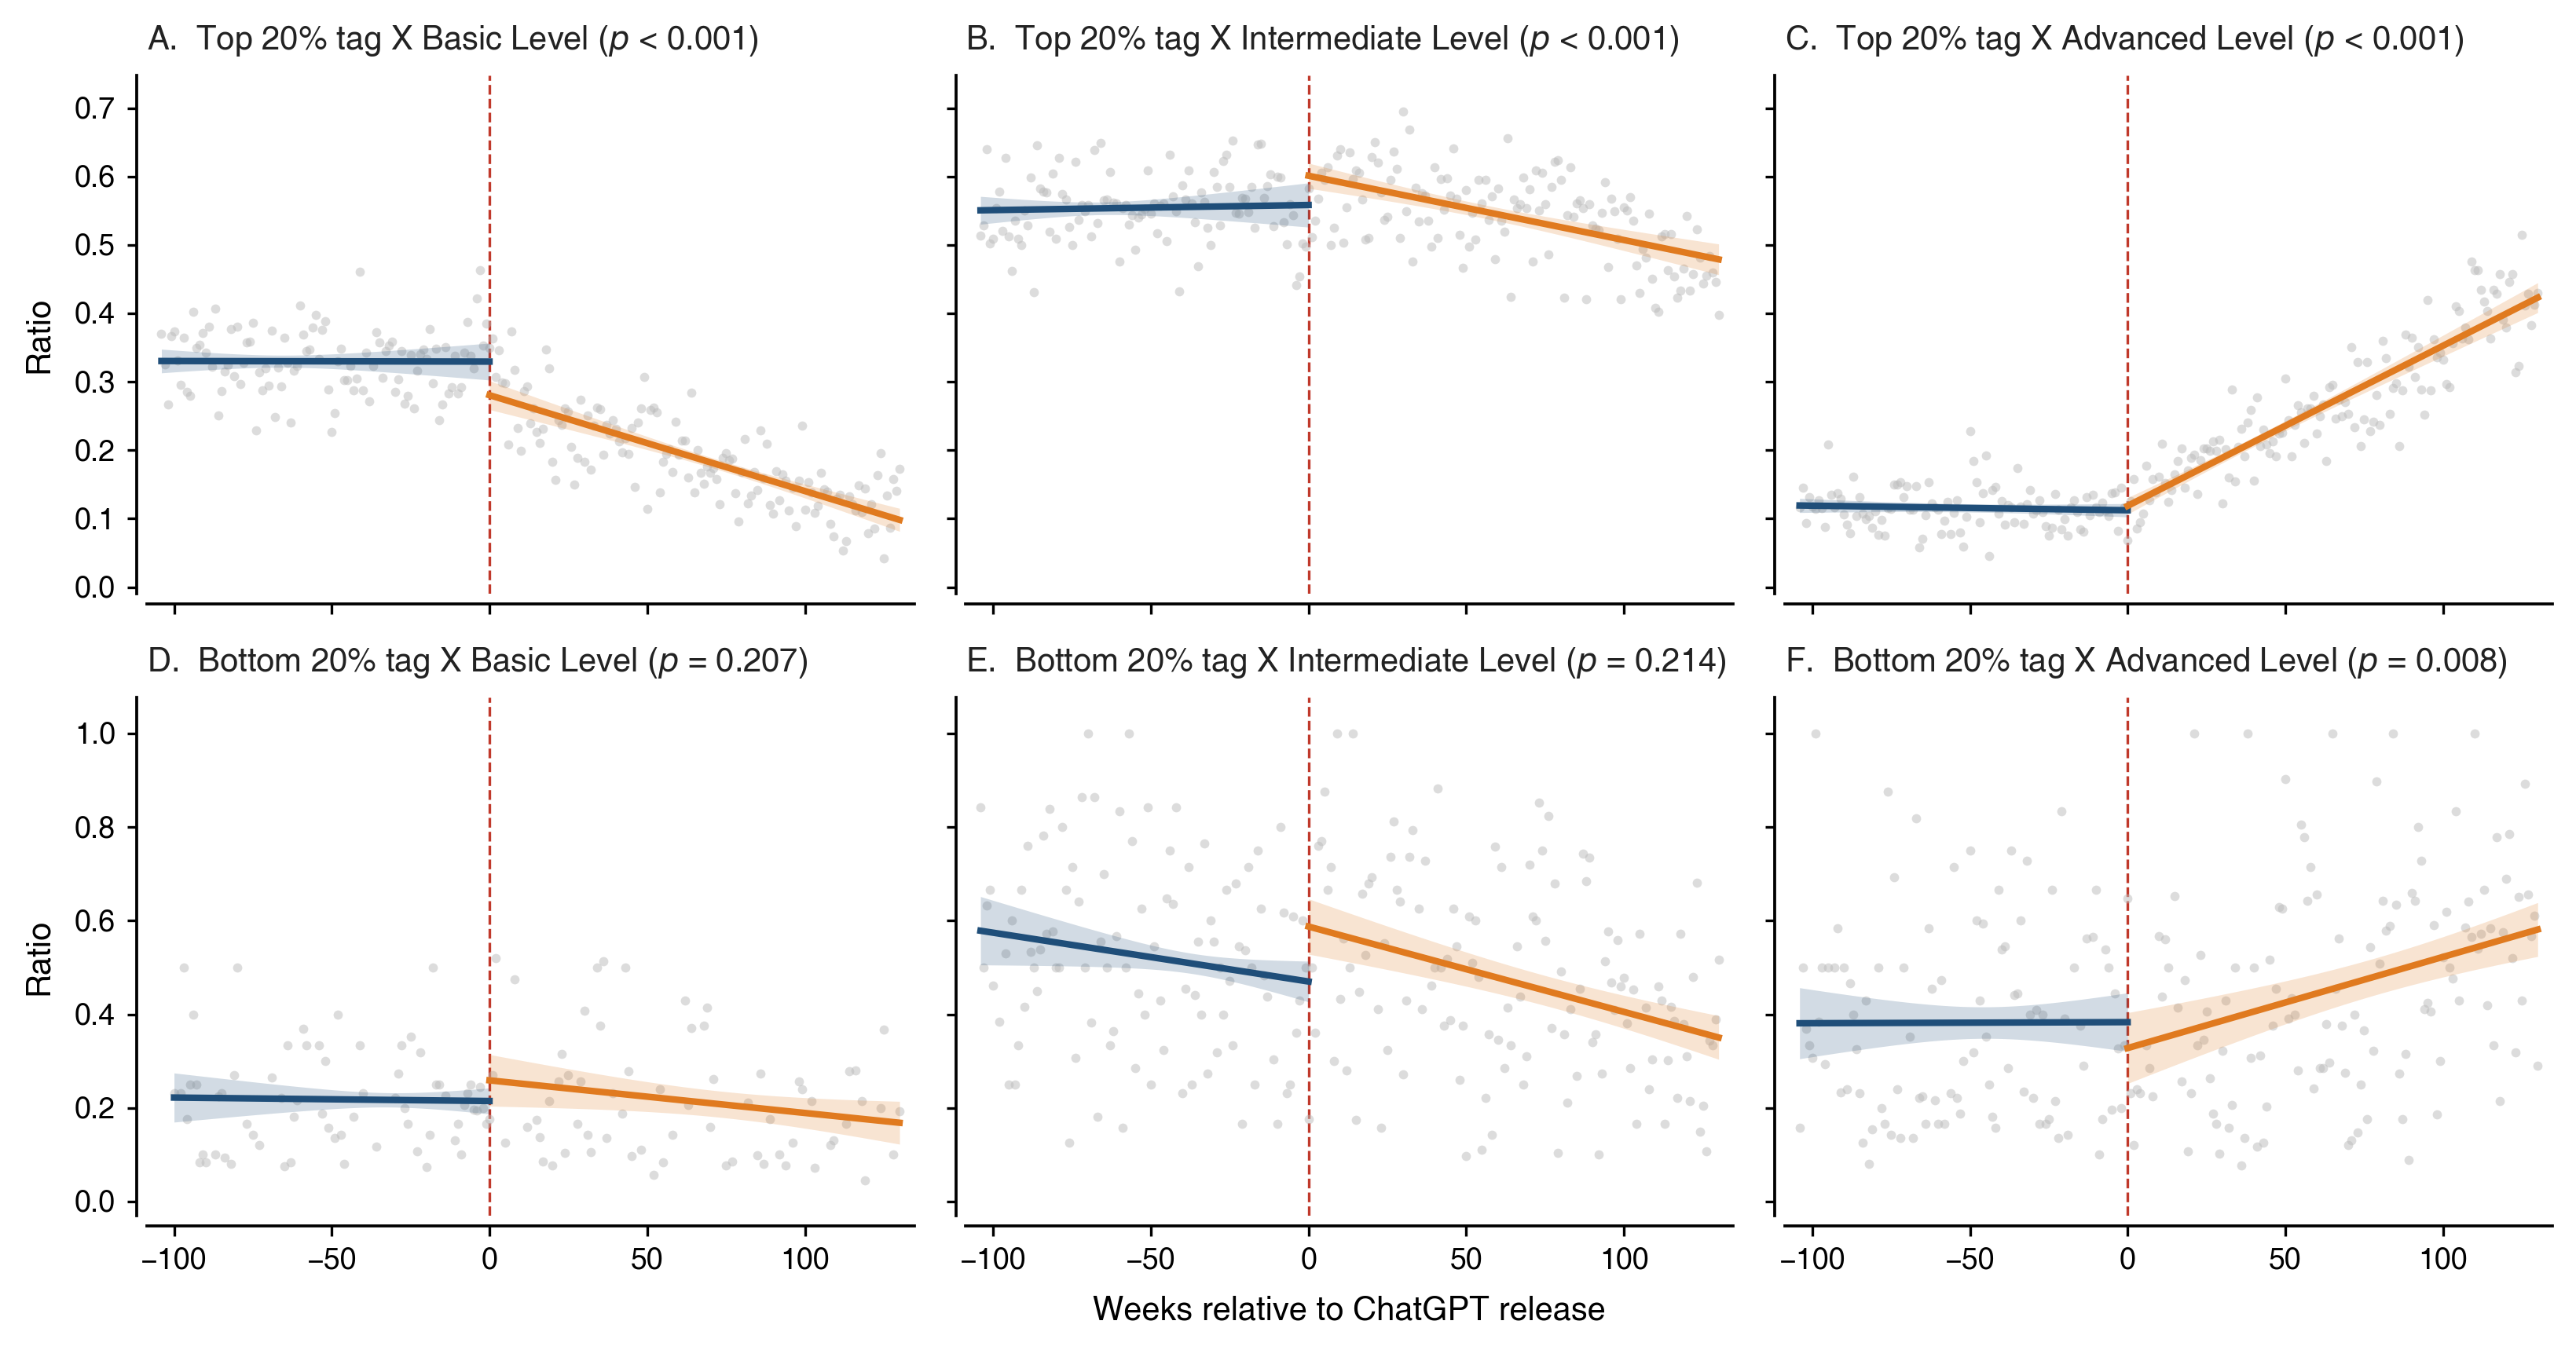

panel result      p(level)    p(slope)     level β     slope β     n
top   0             0.0006      0.0000     -0.0491    -0.00139   235
bot   0             0.1661      0.2072     +0.0441    -0.00062   132
top   1             0.0105      0.0008     +0.0427    -0.00101   235
bot   1             0.0013      0.2143     +0.1174    -0.00078   223
top   2             0.4364      0.0000     +0.0063    +0.00241   235
bot   2             0.2673      0.0080     -0.0554    +0.00192   222


In [37]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import statsmodels.api as sm
from scipy import stats

PALETTE = {
    'primary': '#1f4e79', 'accent': '#E07A1F',
    'event':   '#C0392B', 'point':  '#BBBBBB',
}

mpl.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans'],
    'pdf.fonttype': 42, 'ps.fonttype': 42,
})

results = ['0', '1', '2']
results = ['0', '1', '2']


# ═══════════════════════════════════════════
# ITS 회귀 + 시점별 CI (HAC SE)
# ═══════════════════════════════════════════
def its_fit(sub, hac_lags=8):
    """ITS 회귀 적합 후 모형과 시점별 CI 반환"""
    sub = sub.sort_values('rel_week').reset_index(drop=True)
    sub['post']   = (sub['rel_week'] >= 0).astype(int)
    sub['post_t'] = sub['post'] * sub['rel_week']

    X = sm.add_constant(sub[['rel_week', 'post', 'post_t']])
    y = sub['ratio']
    m = sm.OLS(y, X).fit(cov_type='HAC', cov_kwds={'maxlags': hac_lags})
    return m, sub

def fit_with_ci(m, x_grid, post_flag):
    """주어진 x_grid에서 예측값과 95% CI"""
    post_grid   = np.full_like(x_grid, post_flag, dtype=float)
    post_t_grid = post_grid * x_grid
    X_new = np.column_stack([np.ones_like(x_grid), x_grid, post_grid, post_t_grid])

    fit = X_new @ m.params.values
    cov = m.cov_params().values
    se  = np.sqrt(np.einsum('ij,jk,ik->i', X_new, cov, X_new))
    return fit, fit - 1.96*se, fit + 1.96*se

# ═══════════════════════════════════════════
# 패널 그리기
# ═══════════════════════════════════════════
def plot_panel(ax, sub, r, label, panel_label,
               show_xlabel=False, show_ylabel=False):
    sub = sub.dropna(subset=['ratio'])
    if len(sub) < 10:
        ax.set_visible(False)
        return

    m, sub = its_fit(sub)
    x = sub['rel_week'].values
    y = sub['ratio'].values

    # ITS의 핵심 검정: slope change (post_t)
    p_slope = m.pvalues['post_t']
    n = len(sub)

    # 산점도
    ax.scatter(x, y, s=8, color=PALETTE['point'],
               alpha=0.5, lw=0, zorder=2, clip_on=False)

    # 회귀선 + CI (pre는 post=0, post는 post=1)
    pre  = x < 0
    post = x >= 0
    if pre.sum() > 2:
        xs_pre = np.linspace(x[pre].min(), 0, 100)
        fit, lo, hi = fit_with_ci(m, xs_pre, post_flag=0)
        ax.fill_between(xs_pre, lo, hi,
                        color=PALETTE['primary'], alpha=0.2, lw=0, zorder=3)
        ax.plot(xs_pre, fit, color=PALETTE['primary'], lw=2.0, zorder=5)

    if post.sum() > 2:
        xs_post = np.linspace(0, x[post].max(), 100)
        fit, lo, hi = fit_with_ci(m, xs_post, post_flag=1)
        ax.fill_between(xs_post, lo, hi,
                        color=PALETTE['accent'], alpha=0.2, lw=0, zorder=3)
        ax.plot(xs_post, fit, color=PALETTE['accent'], lw=2.0, zorder=5)

    # 이벤트 점선
    ax.axvline(0, color=PALETTE['event'], lw=0.8, ls='--', zorder=1)

    # Title: slope change의 p값
    p_txt = '$p$ < 0.001' if p_slope < 0.001 else f'$p$ = {p_slope:.3f}'
    prefix = f'{panel_label}.  ' if panel_label else ''
    DIFFICULTY = {'0' : 'Basic', '1' : 'Intermediate', '2' : 'Advanced'}
    ax.set_title(f'{prefix}{label} 20% tag X {DIFFICULTY[r]} Level ({p_txt})',
                 fontsize=10, loc='left', pad=8, color='#222')

    if show_xlabel:
        ax.set_xlabel('Weeks relative to ChatGPT release',
                      fontsize=10, labelpad=6)
    if show_ylabel:
        ax.set_ylabel('Ratio', fontsize=10, labelpad=6)

    ax.tick_params(axis='both', labelsize=9, width=0.8, length=3)
    for s in ['top', 'right']: ax.spines[s].set_visible(False)
    ax.spines['left'].set_linewidth(0.9)
    ax.spines['bottom'].set_linewidth(0.9)
    ax.spines['left'].set_position(('outward', 3))
    ax.spines['bottom'].set_position(('outward', 3))

    ax.grid(False)
    ax.margins(x=0.02, y=0.08)

# ═══════════════════════════════════════════
# 2x3 grid
# ═══════════════════════════════════════════
fig, axes = plt.subplots(2, 3, figsize=(11, 5.8), dpi=300,
                         sharex=True, sharey='row')

panel_labels = [['A', 'B', 'C'], ['D', 'E', 'F']]

for j, r in enumerate(results):
    top_sub = df_top_viz[df_top_viz['result'].astype(str) == r]
    bot_sub = df_bot_viz[df_bot_viz['result'].astype(str) == r]
    plot_panel(axes[0, j], top_sub, r, 'Top',    panel_labels[0][j],
               show_xlabel=False, show_ylabel=(j == 0))
    plot_panel(axes[1, j], bot_sub, r, 'Bottom', panel_labels[1][j],
               show_xlabel=(j == 1), show_ylabel=(j == 0))

plt.tight_layout()
# plt.savefig('top_bot_its.png', dpi=300, bbox_inches='tight', facecolor='white')
# plt.savefig('top_bot_its.pdf',           bbox_inches='tight', facecolor='white')
plt.show()

# ═══════════════════════════════════════════
# ITS 결과 표
# ═══════════════════════════════════════════
print(f"{'panel':<6}{'result':<8}{'p(level)':>12}{'p(slope)':>12}"
      f"{'level β':>12}{'slope β':>12}{'n':>6}")
for r in results:
    for label, df in [('top', df_top_viz), ('bot', df_bot_viz)]:
        sub = df[df['result'].astype(str) == r].dropna(subset=['ratio'])
        m, _ = its_fit(sub)
        print(f"{label:<6}{r:<8}"
              f"{m.pvalues['post']:>12.4f}{m.pvalues['post_t']:>12.4f}"
              f"{m.params['post']:>+12.4f}{m.params['post_t']:>+12.5f}"
              f"{int(m.nobs):>6}")